## TR vs TIME Analysis

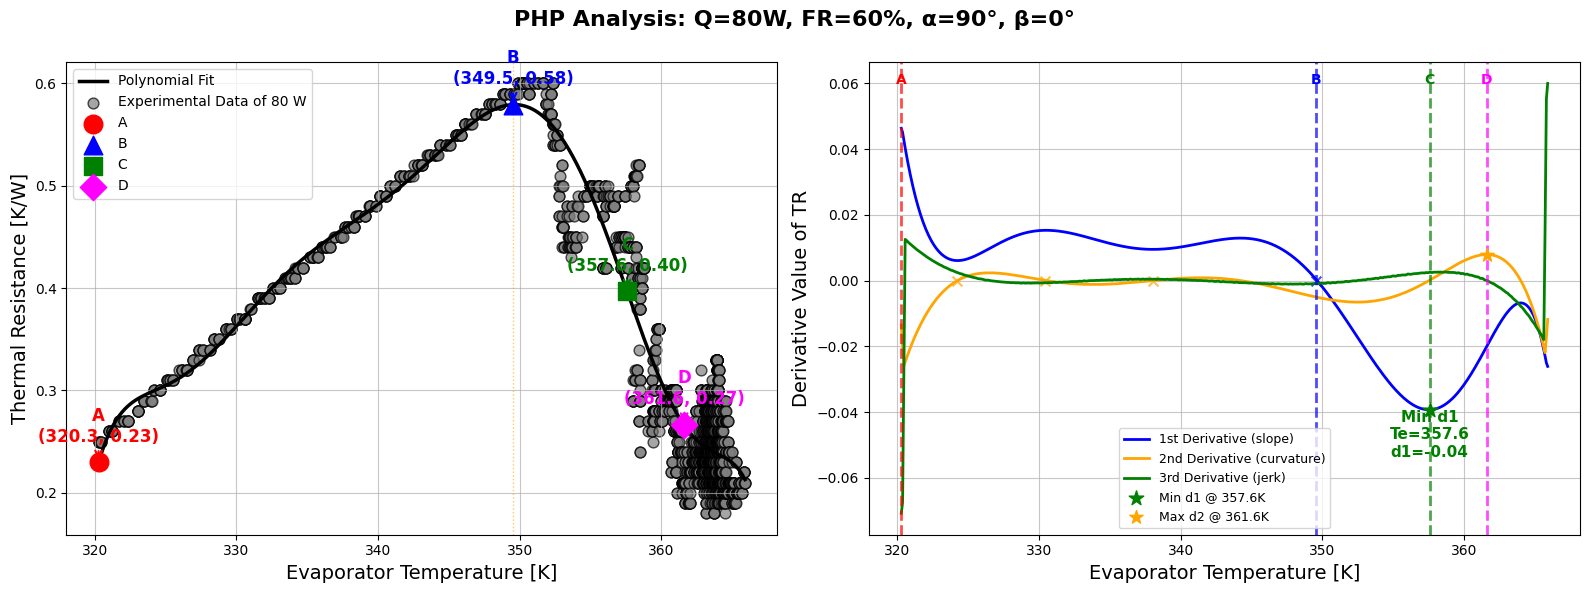

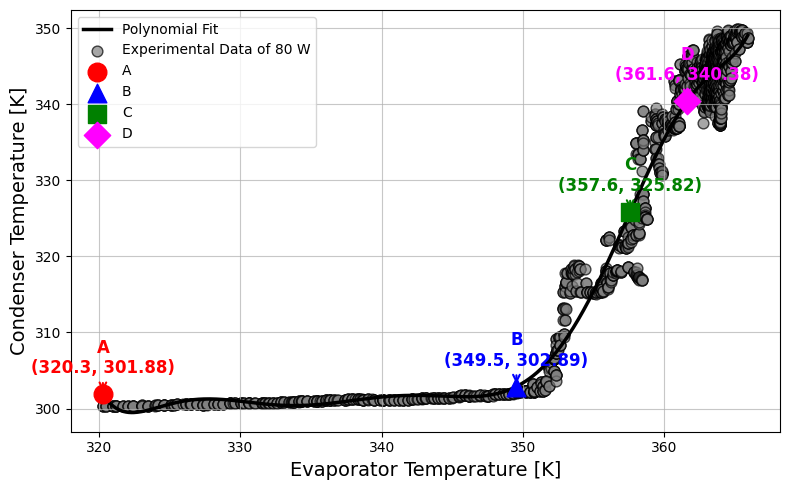

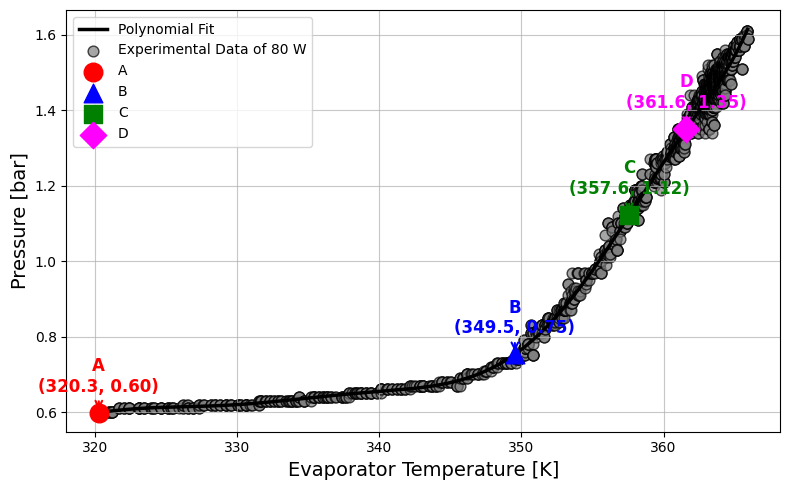

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import zscore
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

# --- TR vs Te Analysis (Code 1) ---

def optimize_polynomial_degree(Te, Y, max_degree=15, min_degree=5, cv_folds=5):
    degrees = range(min_degree, min(max_degree + 1, len(Te) // 3))
    rmse_scores, aic_scores, bic_scores, r2_scores = [], [], [], []
    Te_reshaped = Te.reshape(-1, 1)
    for degree in degrees:
        try:
            poly_pipeline = Pipeline([
                ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
                ('linear', LinearRegression())
            ])
            cv_scores = cross_val_score(poly_pipeline, Te_reshaped, Y, cv=min(cv_folds, len(Te)//2), scoring='neg_root_mean_squared_error')
            rmse_cv = -cv_scores.mean()
            rmse_scores.append(rmse_cv)
            poly_pipeline.fit(Te_reshaped, Y)
            Y_pred = poly_pipeline.predict(Te_reshaped)
            mse = mean_squared_error(Y, Y_pred)
            n = len(Y)
            k = degree + 1
            ss_res = np.sum((Y - Y_pred) ** 2)
            ss_tot = np.sum((Y - np.mean(Y)) ** 2)
            r2 = 1 - (ss_res / ss_tot)
            r2_scores.append(r2)
            aic = n * np.log(mse) + 2 * k
            bic = n * np.log(mse) + k * np.log(n)
            aic_scores.append(aic)
            bic_scores.append(bic)
        except Exception:
            rmse_scores.append(float('inf'))
            aic_scores.append(float('inf'))
            bic_scores.append(float('inf'))
            r2_scores.append(-float('inf'))
    degrees = np.array(degrees)
    rmse_scores = np.array(rmse_scores)
    aic_scores = np.array(aic_scores)
    bic_scores = np.array(bic_scores)
    r2_scores = np.array(r2_scores)
    valid_idx = np.isfinite(rmse_scores)
    if not np.any(valid_idx):
        return {'optimal_degree': 5, 'method': 'default', 'rmse': float('inf')}
    best_rmse_idx = np.argmin(rmse_scores[valid_idx])
    best_aic_idx = np.argmin(aic_scores[valid_idx])
    best_bic_idx = np.argmin(bic_scores[valid_idx])
    best_rmse_degree = degrees[valid_idx][best_rmse_idx]
    best_aic_degree = degrees[valid_idx][best_aic_idx]
    best_bic_degree = degrees[valid_idx][best_bic_idx]
    rmse_norm = (rmse_scores - np.min(rmse_scores[valid_idx])) / (np.max(rmse_scores[valid_idx]) - np.min(rmse_scores[valid_idx]) + 1e-10)
    aic_norm = (aic_scores - np.min(aic_scores[valid_idx])) / (np.max(aic_scores[valid_idx]) - np.min(aic_scores[valid_idx]) + 1e-10)
    composite_scores = 0.6 * rmse_norm + 0.4 * aic_norm
    best_composite_idx = np.argmin(composite_scores[valid_idx])
    best_composite_degree = degrees[valid_idx][best_composite_idx]
    optimal_degree = best_composite_degree
    optimal_rmse = rmse_scores[valid_idx][best_composite_idx]
    optimal_r2 = r2_scores[valid_idx][best_composite_idx]
    return {
        'optimal_degree': int(optimal_degree),
        'method': 'composite_score',
        'rmse': optimal_rmse,
        'r2': optimal_r2,
        'degrees_tested': degrees[valid_idx].tolist(),
        'rmse_scores': rmse_scores[valid_idx].tolist(),
        'aic_scores': aic_scores[valid_idx].tolist(),
        'bic_scores': bic_scores[valid_idx].tolist(),
        'best_rmse_degree': int(best_rmse_degree),
        'best_aic_degree': int(best_aic_degree),
        'best_bic_degree': int(best_bic_degree)
    }

def _find_zero_crossings(arr):
    zero_crossings = []
    for i in range(len(arr) - 1):
        if arr[i] * arr[i + 1] < 0:
            zero_crossings.append(i)
    return np.array(zero_crossings)

def _identify_critical_points(Te_fine, Y_fit, d1, d2, d3):
    # Point A: Always first, minimum Te
    point_A_idx = 0 if len(Te_fine) > 0 else None

    # Point C: 1st derivative zero and maximum TR, always second
    zero_crossings_d1 = _find_zero_crossings(d1)
    point_C_idx = None
    if len(zero_crossings_d1) > 0:
        point_C_idx = zero_crossings_d1[np.argmax(Y_fit[zero_crossings_d1])]
    else:
        point_C_idx = np.argmax(Y_fit)

    # Point B: 1st derivative is minimum and 2nd derivative is closer to zero or equal to zero. Always third, after C
    d1_min_idx = np.argmin(d1[point_C_idx+1:]) + point_C_idx + 1 if point_C_idx is not None and point_C_idx+1 < len(d1) else np.argmin(d1)
    d2_near_zero = np.argmin(np.abs(d2[point_C_idx+1:])) + point_C_idx + 1 if point_C_idx is not None and point_C_idx+1 < len(d2) else np.argmin(np.abs(d2))
    if abs(d2[d1_min_idx]) < 0.1:
        point_B_idx = d1_min_idx
    else:
        point_B_idx = d2_near_zero

    # Point D: 2nd derivative is maximum and 3rd derivative is closer to zero or equal to zero. Always last, after B
    d2_max_idx = np.argmax(d2[point_B_idx+1:]) + point_B_idx + 1 if point_B_idx is not None and point_B_idx+1 < len(d2) else np.argmax(d2)
    d3_near_zero = np.argmin(np.abs(d3[point_B_idx+1:])) + point_B_idx + 1 if point_B_idx is not None and point_B_idx+1 < len(d3) else np.argmin(np.abs(d3))
    if abs(d3[d2_max_idx]) < 0.1:
        point_D_idx = d2_max_idx
    else:
        point_D_idx = d3_near_zero

    # Sequence: A, C, B, D from Te_min to Te_max
    return {
        'A': point_A_idx,
        'C': point_C_idx,
        'B': point_B_idx,
        'D': point_D_idx
    }

def analyze_TR_vs_Te(csv_path, Q, FR, alpha, beta, te_min, te_max, poly_deg='auto', outlier_threshold=2.5, max_poly_deg=15, min_poly_deg=2):
    df = pd.read_csv(csv_path)
    df_sel = df[(df['Q[W]'] == Q) & (df['FR[%]'] == FR) & (df['alpha'] == alpha) & (df['beta'] == beta)]
    df_filtered = df_sel[(df_sel['Te_mean[K]'] >= te_min) & (df_sel['Te_mean[K]'] <= te_max)].copy()
    if df_filtered.empty or 'TR[K/W]' not in df_filtered.columns:
        print("No data found for given condition/range or missing TR[K/W] column.")
        return None
    df_tr_clean = df_filtered[np.abs(zscore(df_filtered['TR[K/W]'])) < outlier_threshold]
    Te = df_tr_clean.sort_values('Te_mean[K]')['Te_mean[K]'].values
    TR = df_tr_clean.sort_values('Te_mean[K]')['TR[K/W]'].values
    if len(Te) <= min_poly_deg:
        print("Insufficient TR data points for analysis.")
        return None
    if poly_deg == 'auto':
        opt_result = optimize_polynomial_degree(Te, TR, max_poly_deg, min_poly_deg)
        poly_deg = opt_result['optimal_degree']
    coeffs = np.polyfit(Te, TR, deg=poly_deg)
    poly = np.poly1d(coeffs)
    Te_fine = np.linspace(Te.min(), Te.max(), 500)
    TR_fit = poly(Te_fine)
    d1 = np.gradient(TR_fit, Te_fine)
    d2 = np.gradient(d1, Te_fine)
    d3 = np.gradient(d2, Te_fine)
    points = _identify_critical_points(Te_fine, TR_fit, d1, d2, d3)
    return {
        'Te_original': Te,
        'Y_original': TR,
        'Te_fine': Te_fine,
        'Y_fit': TR_fit,
        'd1': d1,
        'd2': d2,
        'd3': d3,
        'points': points,
        'poly_coeffs': coeffs,
        'poly_degree': poly_deg,
        'y_label': 'TR',
        'y_unit': 'K/W',
        'rmse': np.sqrt(mean_squared_error(TR, poly(Te))),
        'r2': 1 - np.sum((TR - poly(Te)) ** 2) / np.sum((TR - np.mean(TR)) ** 2)
    }

# --- Tc vs Te and P vs Te Analysis (Code 2, with A/B/C/D from TR) ---

def analyze_heat_pipe_data(csv_path, Q, FR, alpha, beta, te_min, te_max, 
                          poly_deg='auto', outlier_threshold=2.5, 
                          max_poly_deg=15, min_poly_deg=2, tr_points=None, tr_Te_fine=None):
    df = pd.read_csv(csv_path)
    df_sel = df[(df['Q[W]'] == Q) & (df['FR[%]'] == FR) & 
                (df['alpha'] == alpha) & (df['beta'] == beta)]
    df_filtered = df_sel[(df_sel['Te_mean[K]'] >= te_min) & 
                        (df_sel['Te_mean[K]'] <= te_max)].copy()
    if df_filtered.empty:
        print("No data found for given condition and range.")
        return None
    df_tc_clean = df_filtered[np.abs(zscore(df_filtered['Tc_mean[K]'])) < outlier_threshold]
    df_p_clean = df_filtered[np.abs(zscore(df_filtered['P[bar]'])) < outlier_threshold]
    results = {}
    # Tc vs Te
    if len(df_tc_clean) > min_poly_deg:
        Te_tc = df_tc_clean.sort_values('Te_mean[K]')['Te_mean[K]'].values
        Tc_tc = df_tc_clean.sort_values('Te_mean[K]')['Tc_mean[K]'].values
        if poly_deg == 'auto':
            tc_opt_result = optimize_polynomial_degree(Te_tc, Tc_tc, max_poly_deg, min_poly_deg)
            tc_poly_deg = tc_opt_result['optimal_degree']
        else:
            tc_poly_deg = poly_deg
        results['tc'] = _polyfit_and_plot_with_points(Te_tc, Tc_tc, tc_poly_deg, 'Tc_mean [K]', 'Tc vs Te', Q, tr_points, tr_Te_fine)
    else:
        print("Insufficient Tc data points for analysis")
    # P vs Te
    if len(df_p_clean) > min_poly_deg:
        Te_p = df_p_clean.sort_values('Te_mean[K]')['Te_mean[K]'].values
        P_p = df_p_clean.sort_values('Te_mean[K]')['P[bar]'].values
        if poly_deg == 'auto':
            p_opt_result = optimize_polynomial_degree(Te_p, P_p, max_poly_deg, min_poly_deg)
            p_poly_deg = p_opt_result['optimal_degree']
        else:
            p_poly_deg = poly_deg
        results['p'] = _polyfit_and_plot_with_points(Te_p, P_p, p_poly_deg, 'P [bar]', 'P vs Te', Q, tr_points, tr_Te_fine)
    else:
        print("Insufficient P data points for analysis")
    return results

def _polyfit_and_plot_with_points(Te, Y, poly_deg, y_label, title, Q, tr_points, tr_Te_fine):
    coeffs = np.polyfit(Te, Y, deg=poly_deg)
    poly = np.poly1d(coeffs)
    Te_fine = np.linspace(Te.min(), Te.max(), 500)
    Y_fit = poly(Te_fine)
    Y_pred = poly(Te)
    rmse = np.sqrt(mean_squared_error(Y, Y_pred))
    plt.figure(figsize=(8, 5))
    plt.plot(Te_fine, Y_fit, '-', color='black', linewidth=2.5, label=f'Polynomial Fit')
    plt.scatter(Te, Y, color='gray', alpha=0.7, s=60, edgecolor='k', label=f'Experimental Data of {Q} W')
    plt.xlabel('Evaporator Temperature [K]', fontsize=14)
    if y_label == 'Tc_mean [K]':
        plt.ylabel('Condenser Temperature [K]', fontsize=14)
    elif y_label == 'P [bar]':
        plt.ylabel('Pressure [bar]', fontsize=14)
    else:
        plt.ylabel(y_label, fontsize=14)
    #plt.title(title, fontsize=14)
    # Add points A, B, C, D from TR analysis, but swap display names of B and C
    if tr_points is not None and tr_Te_fine is not None:
        colors = {'A': 'red', 'B': 'green', 'C': 'blue', 'D': 'magenta'}
        markers = {'A': 'o', 'B': 's', 'C': '^', 'D': 'D'}
        for label, idx in tr_points.items():
            # Swap display names for B and C
            if label == 'B':
                plot_label = 'C'
            elif label == 'C':
                plot_label = 'B'
            else:
                plot_label = label
            if idx is not None and 0 <= idx < len(Te_fine):
                plt.scatter(Te_fine[idx], Y_fit[idx], color=colors[label], s=180, marker=markers[label], zorder=5, label=f'{plot_label}')
                plt.annotate(f'{plot_label}\n({Te_fine[idx]:.1f}, {Y_fit[idx]:.2f})', (Te_fine[idx], Y_fit[idx]), textcoords="offset points", xytext=(0,15), ha='center', fontsize=12, color=colors[label], fontweight='bold', arrowprops=dict(arrowstyle='->', color=colors[label], lw=1.5))
    plt.legend(fontsize=10, loc='best')
    plt.grid(True, alpha=0.7)
    plt.tight_layout()
    plt.show()
    return {
        'Te': Te,
        'Y': Y,
        'Te_fine': Te_fine,
        'Y_fit': Y_fit,
        'poly_coeffs': coeffs,
        'poly_degree': poly_deg,
        'rmse': rmse
    }

# --- Example usage ---

csv_path = 'database.csv'
Q, FR, alpha, beta = 80, 60, 90, 0
te_min, te_max = 320, 370

# 1. Analyze TR vs Te and get critical points
results_TR = analyze_TR_vs_Te(
    csv_path=csv_path,
    Q=Q, FR=FR, alpha=alpha, beta=beta,
    te_min=te_min, te_max=te_max,
    poly_deg='auto',
    outlier_threshold=2.5,
    max_poly_deg=15,
    min_poly_deg=5
)
tr_points = results_TR['points'] if results_TR is not None else None
tr_Te_fine = results_TR['Te_fine'] if results_TR is not None else None

# --- Plot 1: TR vs Te and Derivatives (side by side, with A/B/C/D marked, B and C swapped in display) ---
if results_TR is not None:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'PHP Analysis: Q={Q}W, FR={FR}%, α={alpha}°, β={beta}°', fontsize=16, fontweight='bold')
    colors = {'A': 'red', 'B': 'green', 'C': 'blue', 'D': 'magenta'}
    markers = {'A': 'o', 'B': 's', 'C': '^', 'D': 'D'}
    data = results_TR
    ax1 = axes[0]
    ax1.plot(data['Te_fine'], data['Y_fit'], '-', color='black', linewidth=2.5, label=f'Polynomial Fit')
    ax1.scatter(data['Te_original'], data['Y_original'], color='gray', alpha=0.7, s=60, edgecolor='k', label=f'Experimental Data of {Q} W')
    for label, idx in data['points'].items():
        # Swap display names for B and C
        if label == 'B':
            plot_label = 'C'
        elif label == 'C':
            plot_label = 'B'
        else:
            plot_label = label
        ax1.scatter(data['Te_fine'][idx], data['Y_fit'][idx], color=colors[label], s=180, marker=markers[label], zorder=5, label=f'{plot_label}')
        ax1.annotate(f'{plot_label}\n({data["Te_fine"][idx]:.1f}, {data["Y_fit"][idx]:.2f})', (data['Te_fine'][idx], data['Y_fit'][idx]), textcoords="offset points", xytext=(0,15), ha='center', fontsize=12, color=colors[label], fontweight='bold', arrowprops=dict(arrowstyle='->', color=colors[label], lw=1.5))
    zero_crossings_d1 = _find_zero_crossings(data['d1'])
    zero_crossings_d2 = _find_zero_crossings(data['d2'])
    for zc in zero_crossings_d1[:3]:
        ax1.axvline(data['Te_fine'][zc], color='orange', linestyle=':', alpha=0.6, linewidth=1)
    
    ax1.set_xlabel('Evaporator Temperature [K]', fontsize=14)
    ax1.set_ylabel('Thermal Resistance [K/W]', fontsize=14)
    #ax1.set_title('TR vs Te with Critical Points', fontsize=14)
    ax1.legend(fontsize=10, loc='best')
    ax1.grid(True, alpha=0.7)
    ax2 = axes[1]
    ax2.plot(data['Te_fine'], data['d1'], label='1st Derivative (slope)', linewidth=2, color='blue')
    ax2.plot(data['Te_fine'], data['d2'], label='2nd Derivative (curvature)', linewidth=2, color='orange')
    ax2.plot(data['Te_fine'], data['d3'], label='3rd Derivative (jerk)', linewidth=2, color='green')
    for label, idx in data['points'].items():
        # Swap display names for B and C
        if label == 'B':
            plot_label = 'C'
        elif label == 'C':
            plot_label = 'B'
        else:
            plot_label = label
        ax2.axvline(data['Te_fine'][idx], color=colors[label], linestyle='--', linewidth=2, alpha=0.7)
        ax2.text(data['Te_fine'][idx], ax2.get_ylim()[1]*0.9, plot_label, color=colors[label], fontweight='bold', ha='center')
    
    # Mark min d1 and write its value at the corresponding Te
    min_d1_idx = np.argmin(data['d1'])
    ax2.scatter(data['Te_fine'][min_d1_idx], data['d1'][min_d1_idx], color='green', s=120, marker='*', zorder=10, label=f'Min d1 @ {data["Te_fine"][min_d1_idx]:.1f}K')
    ax2.text(data['Te_fine'][min_d1_idx], data['d1'][min_d1_idx], f'Min d1\nTe={data["Te_fine"][min_d1_idx]:.1f}\nd1={data["d1"][min_d1_idx]:.2f}', color='green', fontsize=11, fontweight='bold', ha='center', va='top')
    max_d1_idx = np.argmax(data['d1'])
    max_d2_idx = np.argmax(data['d2'])
    max_d3_idx = np.argmax(np.abs(data['d3']))
    ax2.scatter(data['Te_fine'][max_d2_idx], data['d2'][max_d2_idx], color='orange', s=100, marker='*', zorder=10, label=f'Max d2 @ {data["Te_fine"][max_d2_idx]:.1f}K')
    for zc in zero_crossings_d1[:3]:
        ax2.scatter(data['Te_fine'][zc], 0, color='blue', s=50, marker='x', alpha=0.7)
    for zc in zero_crossings_d2[:3]:
        ax2.scatter(data['Te_fine'][zc], 0, color='orange', s=50, marker='x', alpha=0.7)

    ax2.set_xlabel('Evaporator Temperature [K]', fontsize=14)
    ax2.set_ylabel('Derivative Value of TR', fontsize=14)
    #ax2.set_title('Derivatives of TR vs Te', fontsize=14)
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.7)
    plt.tight_layout()
    plt.show()

# 2. Analyze and plot Tc vs Te and P vs Te, marking A/B/C/D from TR (B and C swapped in display)
results = analyze_heat_pipe_data(
    csv_path=csv_path,
    Q=Q, FR=FR, alpha=alpha, beta=beta,
    te_min=te_min, te_max=te_max,
    poly_deg='auto',
    outlier_threshold=2.5,
    max_poly_deg=15,
    min_poly_deg=5,
    tr_points=tr_points,
    tr_Te_fine=tr_Te_fine
)

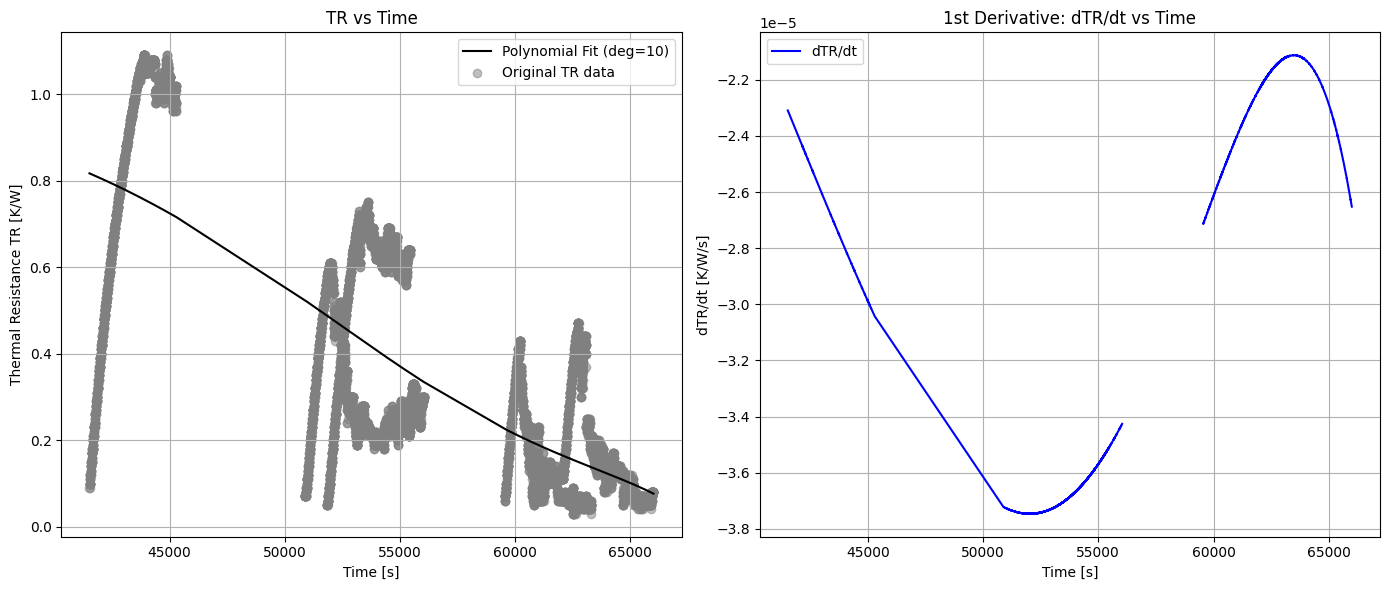

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

# Step 1: Load Data
df = pd.read_csv("database.csv")

# Step 2: Convert TIME column (hh:mm:ss) to seconds
df['time_in_sec'] = pd.to_timedelta(df['TIME']).dt.total_seconds()

# Step 3: Select and clean TR vs Time data
df_tr = df[['time_in_sec', 'TR[K/W]']].dropna()
df_tr = df_tr[df_tr['TR[K/W]'] > 0]  # Remove non-physical values

# Sort by time
df_tr = df_tr.sort_values('time_in_sec')
time = df_tr['time_in_sec'].values
TR = df_tr['TR[K/W]'].values

# Step 4: Fit Polynomial (auto-degree selection)
def auto_poly_fit(X, Y, min_deg=3, max_deg=10):
    best_score = float('inf')
    best_deg = min_deg
    best_model = None
    for deg in range(min_deg, max_deg + 1):
        model = Pipeline([
            ('poly', PolynomialFeatures(degree=deg, include_bias=False)),
            ('linreg', LinearRegression())
        ])
        scores = cross_val_score(model, X.reshape(-1, 1), Y, scoring='neg_root_mean_squared_error', cv=5)
        score = -np.mean(scores)
        if score < best_score:
            best_score = score
            best_deg = deg
            best_model = model
    best_model.fit(X.reshape(-1, 1), Y)
    return best_model, best_deg

model, best_deg = auto_poly_fit(time, TR)
TR_fit = model.predict(time.reshape(-1, 1))

# Step 5: Derivatives (dTR/dt)
TR_fit_smooth = TR_fit
dTR_dt = np.gradient(TR_fit_smooth, time)

# Step 6: Plot TR vs Time and Derivative
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: TR vs Time
ax[0].plot(time, TR_fit_smooth, label=f'Polynomial Fit (deg={best_deg})', color='black')
ax[0].scatter(time, TR, label='Original TR data', alpha=0.5, color='gray')
ax[0].set_title('TR vs Time')
ax[0].set_xlabel('Time [s]')
ax[0].set_ylabel('Thermal Resistance TR [K/W]')
ax[0].legend()
ax[0].grid(True)

# Plot 2: dTR/dt vs Time
ax[1].plot(time, dTR_dt, label='dTR/dt', color='blue')
ax[1].set_title('1st Derivative: dTR/dt vs Time')
ax[1].set_xlabel('Time [s]')
ax[1].set_ylabel('dTR/dt [K/W/s]')
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()


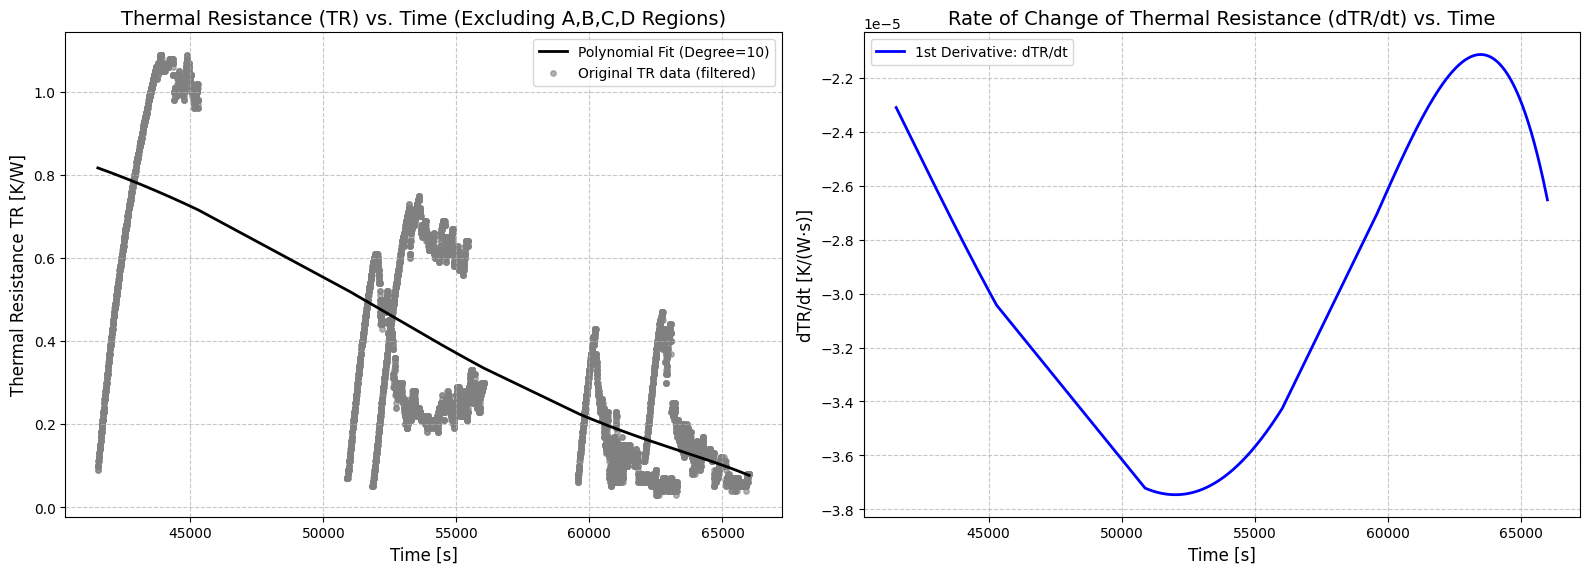

Best polynomial degree found: 10


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

# Step 1: Load Data
df = pd.read_csv("database.csv")

# Step 2: Convert TIME column (hh:mm:ss) to total seconds
df['TIME_in_sec'] = pd.to_timedelta(df['TIME']).dt.total_seconds()

# Step 3: Define time ranges for points A, B, C, and D to be excluded
# !!! IMPORTANT: ADJUST THESE RANGES BASED ON YOUR ACTUAL DATA !!!
# You might need to plot the original data first to find the exact time windows for A, B, C, D.
exclude_ranges = [
    (500, 1000),  # Approximate range for point A
    (2000, 2500), # Approximate range for point B
    (3500, 4000), # Approximate range for point C
    (5000, 5500)  # Approximate range for point D
]

# Step 4: Select and clean TR vs Time data
df_tr = df[['TIME_in_sec', 'TR[K/W]']].dropna()
df_tr = df_tr[df_tr['TR[K/W]'] > 0]   # Remove non-physical values (e.g., zero or negative TR)

# Filter out data points within the defined exclusion ranges
original_df_tr_before_filtering = df_tr.copy() # Keep a copy to plot excluded points if needed

for start_time, end_time in exclude_ranges:
    df_tr = df_tr[~((df_tr['TIME_in_sec'] >= start_time) & (df_tr['TIME_in_sec'] <= end_time))]

# Sort by time to ensure correct derivative calculation
df_tr = df_tr.sort_values('TIME_in_sec')
time = df_tr['TIME_in_sec'].values
TR = df_tr['TR[K/W]'].values

# Step 5: Fit Polynomial (auto-degree selection using cross-validation)
def auto_poly_fit(X, Y, min_deg=3, max_deg=10):
    best_score = float('inf')
    best_deg = min_deg
    best_model = None
    for deg in range(min_deg, max_deg + 1):
        model = Pipeline([
            ('poly', PolynomialFeatures(degree=deg, include_bias=False)),
            ('linreg', LinearRegression())
        ])
        scores = cross_val_score(model, X.reshape(-1, 1), Y, scoring='neg_root_mean_squared_error', cv=5)
        score = -np.mean(scores)
        if score < best_score:
            best_score = score
            best_deg = deg
            best_model = model
    best_model.fit(X.reshape(-1, 1), Y)
    return best_model, best_deg

model, best_deg = auto_poly_fit(time, TR)

# Predict TR for the *entire original time range* for a smooth fit across the gaps
# This ensures the polynomial fit is continuous, even where data was excluded.
# We use the 'time' from the original (unfiltered) data for prediction to see the full curve.
full_time_range = original_df_tr_before_filtering['TIME_in_sec'].values
full_time_range = np.sort(np.unique(full_time_range)) # Ensure sorted unique times
TR_fit_full_range = model.predict(full_time_range.reshape(-1, 1))


# Step 6: Calculate Derivatives (dTR/dt) for the full, smoothed range
dTR_dt_full_range = np.gradient(TR_fit_full_range, full_time_range)

# Step 7: Plot TR vs TIME and Derivative dTR/dt vs TIME
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: TR vs TIME
ax[0].plot(full_time_range, TR_fit_full_range, label=f'Polynomial Fit (Degree={best_deg})', color='black', linewidth=2)
ax[0].scatter(time, TR, label='Original TR data (filtered)', alpha=0.6, color='gray', s=15)

# Optionally, plot the excluded points to visualize what was removed
excluded_points_df = original_df_tr_before_filtering[~original_df_tr_before_filtering['TIME_in_sec'].isin(time)]
if not excluded_points_df.empty:
    ax[0].scatter(excluded_points_df['TIME_in_sec'], excluded_points_df['TR[K/W]'],
                  label='Excluded points (A, B, C, D regions)', alpha=0.8, color='red', s=20, marker='x')


ax[0].set_title('Thermal Resistance (TR) vs. Time (Excluding A,B,C,D Regions)', fontsize=14)
ax[0].set_xlabel('Time [s]', fontsize=12)
ax[0].set_ylabel('Thermal Resistance TR [K/W]', fontsize=12)
ax[0].legend(fontsize=10)
ax[0].grid(True, linestyle='--', alpha=0.7)
ax[0].tick_params(axis='both', which='major', labelsize=10)


# Plot 2: dTR/dt vs TIME
ax[1].plot(full_time_range, dTR_dt_full_range, label='1st Derivative: dTR/dt', color='blue', linewidth=2)
ax[1].set_title('Rate of Change of Thermal Resistance (dTR/dt) vs. Time', fontsize=14)
ax[1].set_xlabel('Time [s]', fontsize=12)
ax[1].set_ylabel('dTR/dt [K/(W·s)]', fontsize=12)
ax[1].legend(fontsize=10)
ax[1].grid(True, linestyle='--', alpha=0.7)
ax[1].tick_params(axis='both', which='major', labelsize=10)

plt.tight_layout()
plt.show()

print(f"Best polynomial degree found: {best_deg}")